# Research Questions   
Does humidity have a measurable effect on electricity consumption?

Are there seasonal patterns in how humidity impacts demand?

In [2]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import data 
data = pd.read_csv("/Users/jiehni/monash/ads1002/ADS1002-project/data/processed/master_data.csv")

print(data.shape)

# drop missing values
print(data["Humidity (%)"].isna().sum())
data = data.dropna(subset=["Humidity (%)"])
print(data["Humidity (%)"].isna().sum())

(1680717, 8)
1309
0


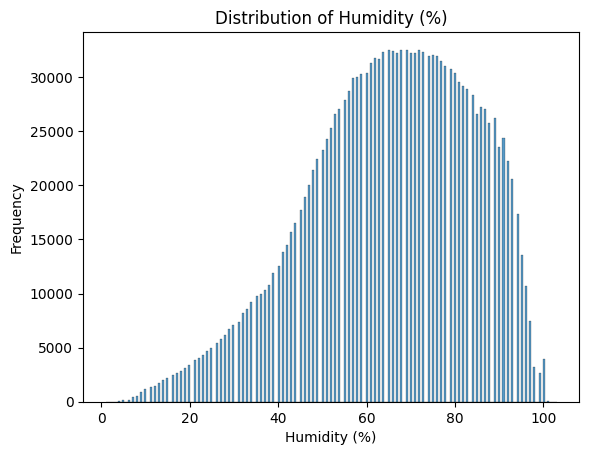

In [3]:
# plot histogram of the distribution of humidity 
sns.histplot(data["Humidity (%)"])
plt.title("Distribution of Humidity (%)")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.show()

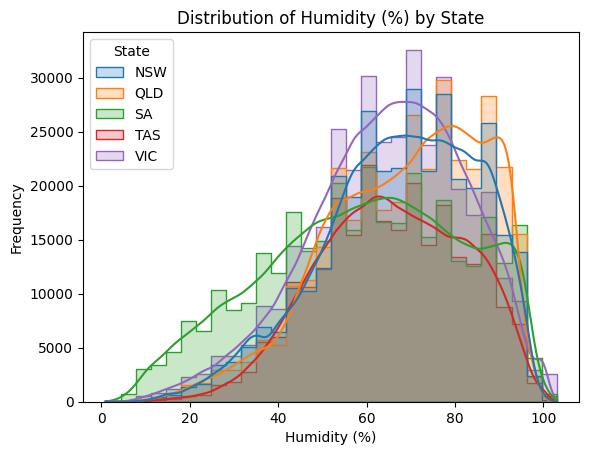

In [4]:
# plot histogram of the distribution of humidity by state
sns.histplot(data=data, x="Humidity (%)", hue="State", bins=30, kde=True, element="step")
plt.title("Distribution of Humidity (%) by State")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.show()


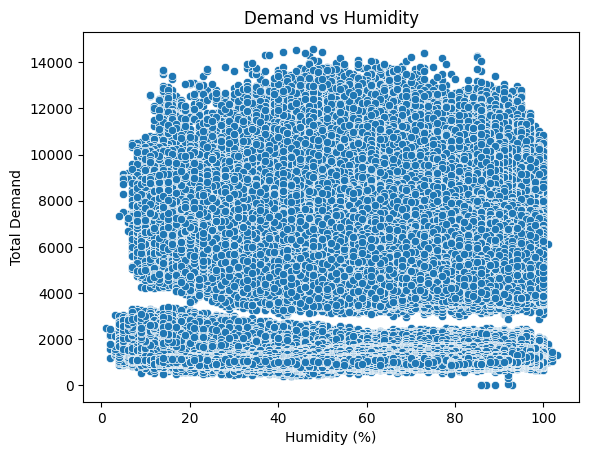

/Users/jiehni/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


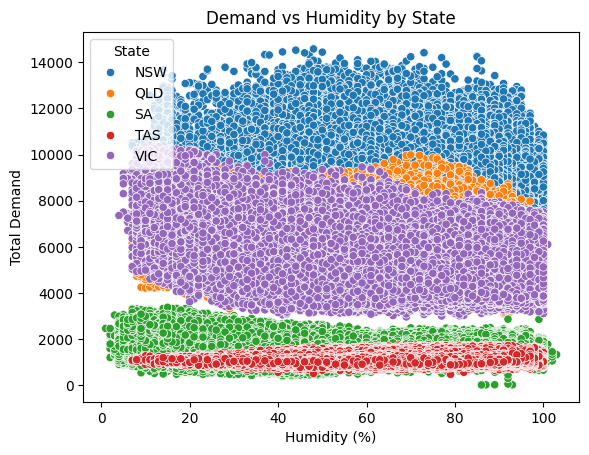

In [5]:
# plot scatterplot of humidity vs total demand
sns.scatterplot(data=data, x="Humidity (%)", y="Total Demand")
plt.title("Demand vs Humidity")
plt.show()

# plot scatterplot of humidity vs total demand by state
sns.scatterplot(data=data, x="Humidity (%)", y="Total Demand", hue="State")
plt.title("Demand vs Humidity by State")
plt.show()

/var/folders/0d/qf_dfhwn3vjd4fvry35670240000gn/T/ipykernel_93503/2187668146.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(8000, len(g)), random_state=42))


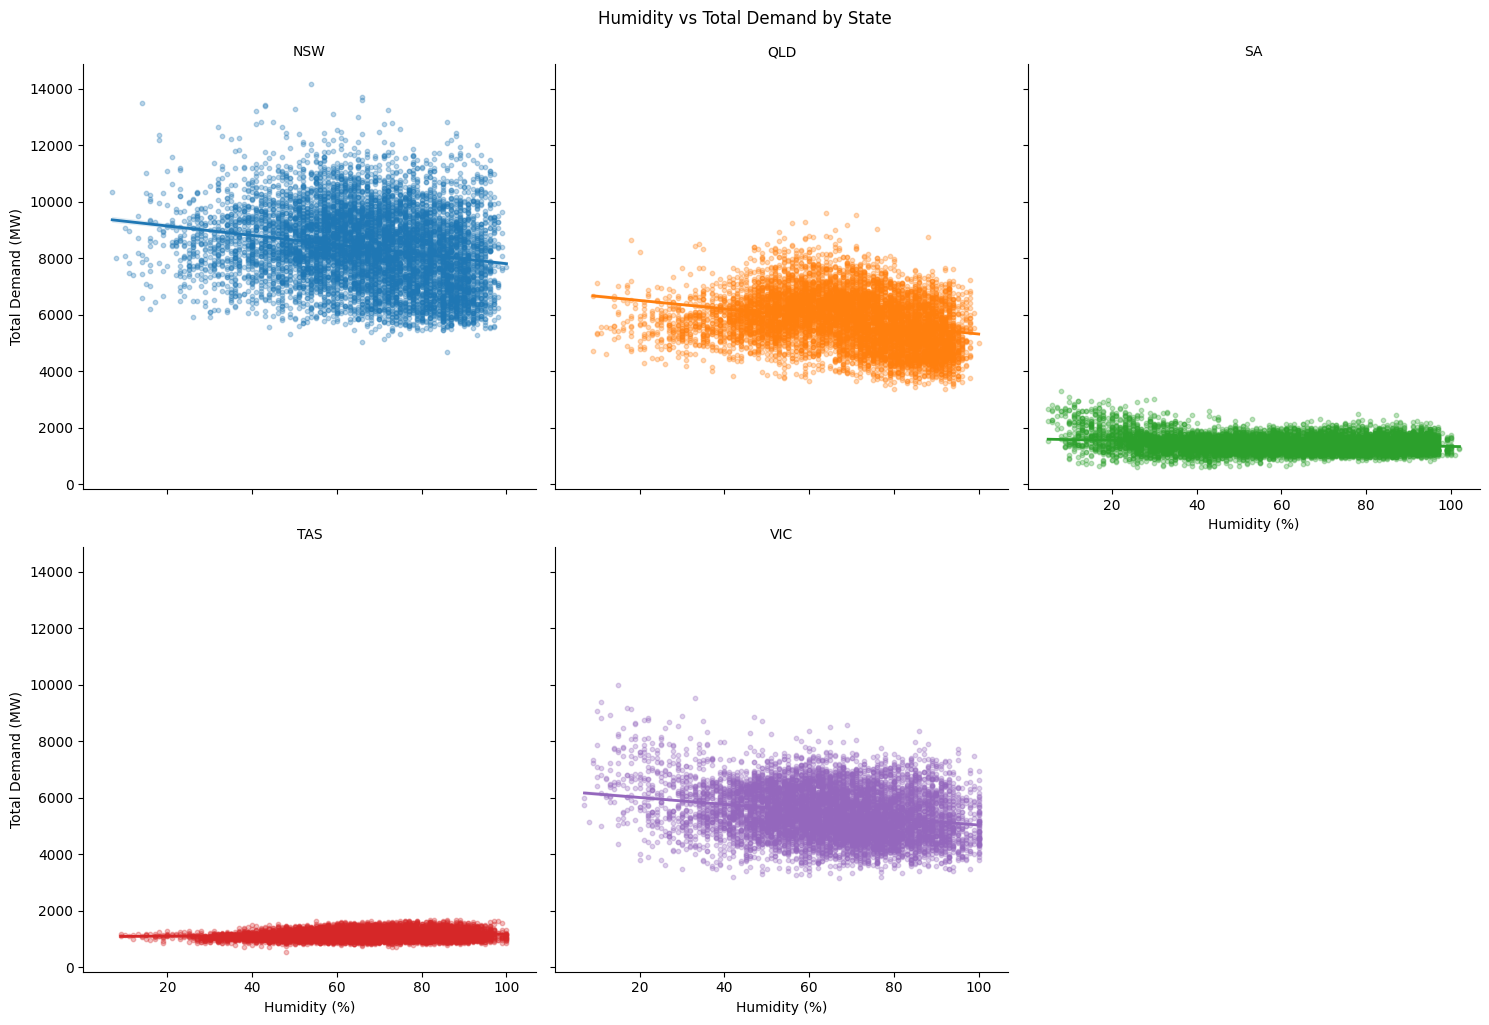

In [6]:
# downsample data, random sample up to 8000 rows per state
df_sample = (
    data.groupby("State", group_keys=False)
        .apply(lambda g: g.sample(n=min(8000, len(g)), random_state=42))
        .reset_index(drop=True)
)

# plot lmplot of humidity vs total demand (scatter plot + linear regression line) and separate into states
g = sns.lmplot(
    data=df_sample,
    x="Humidity (%)", y="Total Demand",
    hue="State",
    col="State", col_wrap=3,
    scatter_kws={"s": 10, "alpha": 0.3},
    line_kws={"lw": 2}
)
g.set_axis_labels("Humidity (%)", "Total Demand (MW)")
g.set_titles("{col_name}")
g.fig.suptitle("Humidity vs Total Demand by State", y=1.02)
plt.show()


/Users/jiehni/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


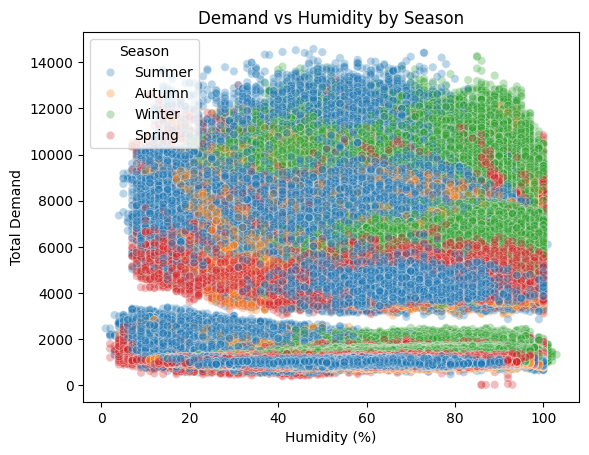

In [10]:
# extract month
data["Month"] = pd.to_datetime(data["Datetime"]).dt.month

# convert month to season
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"
data["Season"] = data["Month"].apply(get_season)

# plot scatterplot of humidity vs total demand by season
sns.scatterplot(data=data, x="Humidity (%)", y="Total Demand", hue="Season", alpha=0.3)
plt.title("Demand vs Humidity by Season")
plt.show()

/var/folders/0d/qf_dfhwn3vjd4fvry35670240000gn/T/ipykernel_79225/2998198933.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly = data.groupby(["Humidity Band","Hour"])["Total Demand"].mean().reset_index()


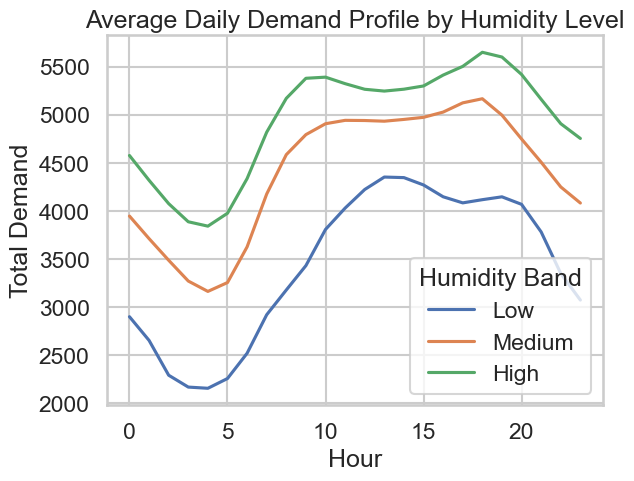

In [79]:
# group humidity into bands 0-33%, 33-67%, 67-100%
data["Humidity Band"] = pd.cut(data["Humidity (%)"], bins=[0,33,67,100], labels=["Low","Medium","High"])

# Extract hour from datetime
data["Datetime"] = pd.to_datetime(data["Datetime"])
data["Hour"] = data["Datetime"].dt.hour

# create hourly data df
hourly = data.groupby(["Humidity Band","Hour"])["Total Demand"].mean().reset_index()

# plot line plot of hourly data vs demand by humidity band
sns.lineplot(data=hourly, x="Hour", y="Total Demand", hue="Humidity Band")
plt.title("Average Daily Demand Profile by Humidity Level")
plt.show()

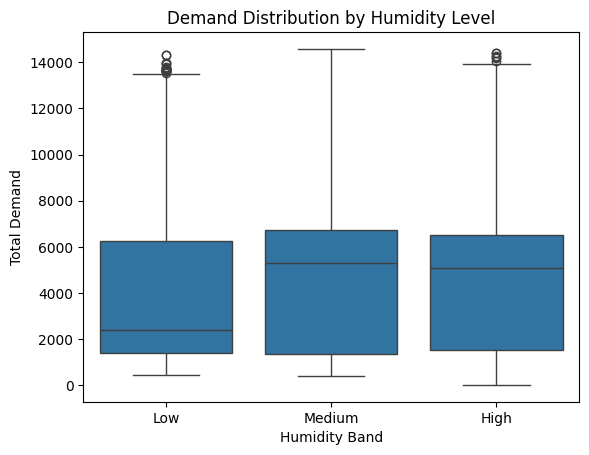

In [15]:
# plot box plot of the demand distribution by humidity band
sns.boxplot(data=data, x="Humidity Band", y="Total Demand")
plt.title("Demand Distribution by Humidity Level")
plt.show()

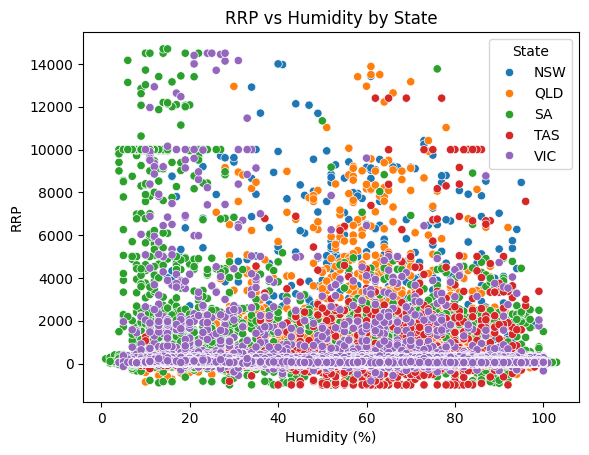

In [16]:
# plot scatter plot of humidity vs rrp by state
sns.scatterplot(data=data, x="Humidity (%)", y="RRP", hue="State")
plt.title("RRP vs Humidity by State")
plt.show()

- Does not look like there is a strong relationship between RRP and humidity
- In fact, according to the heat map, there is a negative -0.043 linear relationship between the two variables

<function matplotlib.pyplot.show(close=None, block=None)>

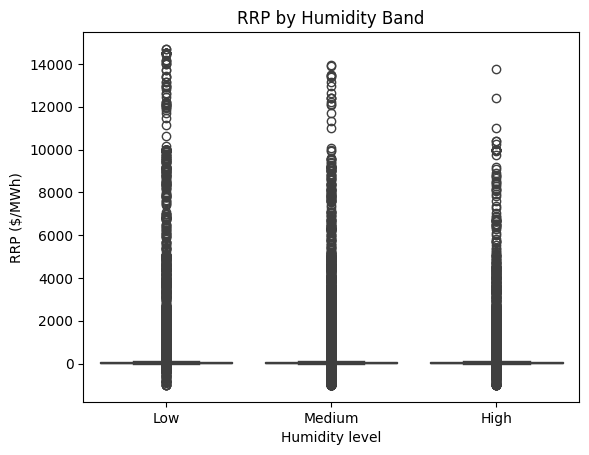

In [18]:
# plot box plot of the rrp distribution by humidity band
sns.boxplot(data=data, x="Humidity Band", y="RRP")
plt.title("RRP by Humidity Band")
plt.xlabel("Humidity level")
plt.ylabel("RRP ($/MWh)")
plt.show

In [89]:
# import statsmodels
import statsmodels.formula.api as smf

# rename columns
data = data.rename(columns={"Humidity (%)": "Humidity", "Total Demand": "Demand"})

# perform ordinary least squares regression and r^2 and for each state
for state in data['State'].unique():
    model = smf.ols("Demand ~ Humidity", data=data[data['State']==state]).fit()
    print(
        f"{state}: Intercept={model.params['Intercept']:.2f}, "
        f"Slope={model.params['Humidity']:.2f}, "
        f"R²={model.rsquared:.4f}"
    )


NSW: Intercept=9418.81, Slope=-16.19, R²=0.0426
QLD: Intercept=6787.25, Slope=-14.75, R²=0.0791
SA: Intercept=1586.00, Slope=-2.40, R²=0.0299
TAS: Intercept=1082.18, Slope=0.78, R²=0.0070
VIC: Intercept=6239.14, Slope=-11.78, R²=0.0542


Observations:

NSW (Intercept 9419, Humidity -16.2, R²=0.0426)
- Demand decreases by ~16 MW for every +1% humidity. Strongest negative slope.
- Humidity explains only 4.3% of the variability in demand.

QLD (Intercept 6787, Humidity -14.7, R²=0.0791)
- Demand decreases ~15 MW per +1% humidity. Similar pattern to NSW.
- Humidity explains ~8% of demand variation.

SA (Intercept 1586, Humidity -2.4, R²=0.0299)
- Small negative slope, ~2 MW less per +1% humidity. Effect is weaker.
- Very weak explanatory power.

TAS (Intercept 1082, Humidity +0.78, R²=0.0070)
- Tiny positive slope, demand slightly increases with humidity.
- Essentially no relationship.

VIC (Intercept 6239, Humidity -11.8, R²=0.0542)
- Demand decreases ~12 MW per +1% humidity. Negative relationship like NSW/QLD.
- Slightly stronger than NSW, but still weak.

Conclusions:

NSW, QLD, VIC: Strong negative humidity–demand relationship.
- Possibly because high humidity often coincides with cooler, cloudy, rainy weather → less air conditioning use.
- Or temperature drives demand, not humidity.

SA: Very weak negative slope.
- Humidity doesn’t seem to matter much.

TAS: Small positive slope.
- Could be noise, or local conditions.

While regression slopes show a negative relationship between humidity and demand in NSW, QLD, and VIC, the low R² values (<10%) suggest humidity alone is not a strong predictor. It likely interacts with other weather variables (temperature, seasonality) to influence demand.